<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/08-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

One of the most straightforward tasks we can perform on a data set without labels is to find groups of data in our dataset which are similar to one another -- what we call clusters.

K-Means is one of the most popular "clustering" algorithms. K-means stores k centroids that it uses to define clusters. A point is considered to be in a particular cluster if it is closer to that cluster's centroid than any other centroid.

K-Means finds the best centroids by alternating between (1) assigning data points to clusters based on the current centroids (2) chosing centroids (points which are the center of a cluster) based on the current assignment of data points to clusters.

## Dataset: MNIST

### MNIST dataset — a brief overview

**Introduction**
The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used benchmark in machine learning. It contains images of handwritten digits and is often used to teach and test classification and clustering techniques.

**Description**
- Type: Handwritten digit images  
- Size: 70,000 grayscale images (28 × 28 pixels)  
  - Training set: 60,000 images  
  - Test set: 10,000 images  
- Classes: 10 (digits 0–9)  
- Format: Each example is a flattened 784-dimensional vector (28×28 pixels) or a 28×28 image with pixel values in [0, 255].  

**Why use MNIST?**
- It is commonly used as a 'toy' dataset in machine learning.
- Simple and well-structured, so students can focus on methods rather than data cleaning.
- Large enough to illustrate practical issues (scaling, dimensionality reduction, speed) but small enough to run on a laptop when sampled.

**Accessing MNIST**
Use scikit-learn's `fetch_openml` to download the MNIST dataset:

```python
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml('mnist_784', version=1, parser='auto')
        X, y = mnist['data'], mnist['target']
```

Format returned by `fetch_openml('mnist_784')`:
- `X`: a table-like object with 70,000 rows and 784 columns; each row is a flattened 28×28 image (pixels ordered 0...783). Pixel values are typically in the range 0–255.  
- `y`: labels for each row (digits 0–9), often returned as strings; convert to integers with `y = y.astype(int)` if desired.  
  

Quick note: to visualize a row as an image use: `X.iloc[i].values.reshape(28,28)` (or `X.values[i].reshape(28,28)`), then display with `plt.imshow(...)`.

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
import seaborn as sns

# Set global random seed for the notebook
np.random.seed(42)

In [ ]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version = 1, parser = 'auto')
X, y = mnist['data'], mnist['target']

The MNIST digits in this set are flattened arrays of 784 pixels. We can reshape them to 28x28 pixels and plot them using matplotlib.

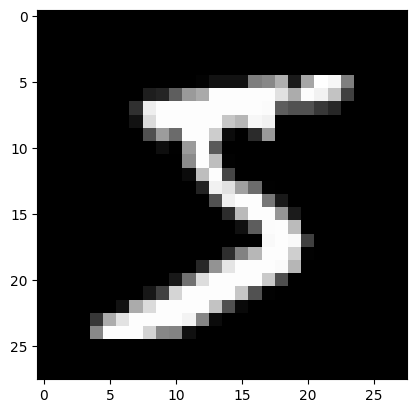

In [ ]:
y = y.astype(int)
image = X.iloc[0, :].values.reshape((28, 28))
plt.imshow(image, cmap='gray')

### 1. Preparing the Data

a. Using the full dataset, *normalize* each image so that the minimum value is 0, and the maximum is 1. This is a standard practice for image datasets.  (Hint: the maximum pixel value is 255, the minimum is 0. How can we rescale this so the maximum is 1?)


In [ ]:


X_scaled = X/255.0


b. Get a random sample of 10% of the data. You will use this sample for the remainder of the questions to reduce computation time.

In [ ]:
sample_X = X_scaled.sample(frac=0.1, random_state=42)
sample_y = y.loc[sample_X.index]

### 2. Fitting k-Means

a. Using the MNIST subset, determine the optimal k value for k-means according to the WCSS elbow method. Use a range of k-values from 2 - 15. (Hint: The plot will not be cut and dry like some of the class examples; just use your best judgement!)

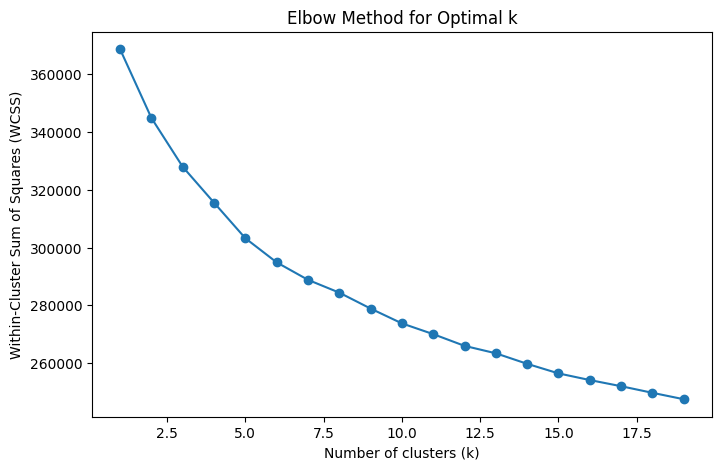

In [ ]:
wcss = []


for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sample_X)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 20), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

b. Fit a k-means model with the optimal k value.

In [ ]:
optimal_k = 15
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=15)
kmeans.fit(sample_X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

c. High-dimensional data—like MNIST digit images with 784 pixels—are hard to visualize.  
**Dimensionality reduction** helps us find a lower-dimensional view that keeps important patterns.

**Principal Component Analysis (PCA)** is a simple and fast method that finds directions of maximum variation in the data. By keeping only the top two directions, we can make a 2D version of our data that’s easy to plot.

Use **PCA** to reduce the MNIST data to **2 dimensions** (`n_components=2`).  
Then make a **scatterplot** of the 2D data and **color the points by their k-means cluster labels**. Use the Dark2 colormap to help distingish the colors. It will also be helpful to shrink the point size (e.g., s = 0.5).

**Hint:** Use [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).


In [ ]:
pca = PCA(n_components=2)

In [ ]:
X_pca = pca.fit_transform(sample_X)

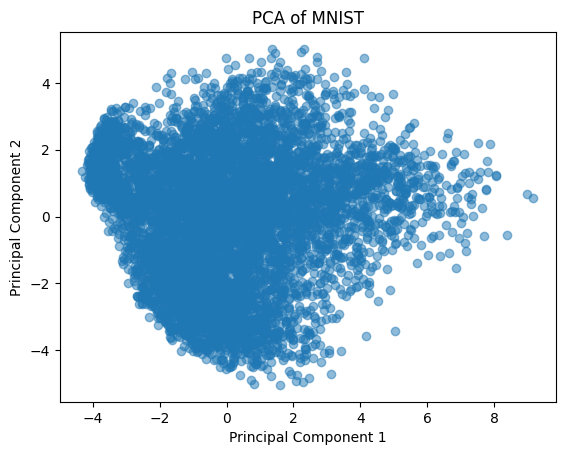

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST')
plt.show()

d. Create two side-by-side scatterplots using the PCA representation (first two principal components) using plt.subplots. Color the first fig according to the true labels and the second according to k-means cluster labels. Be sure to include proper figure titles and a legend.

Text(0, 0.5, 'PC2')

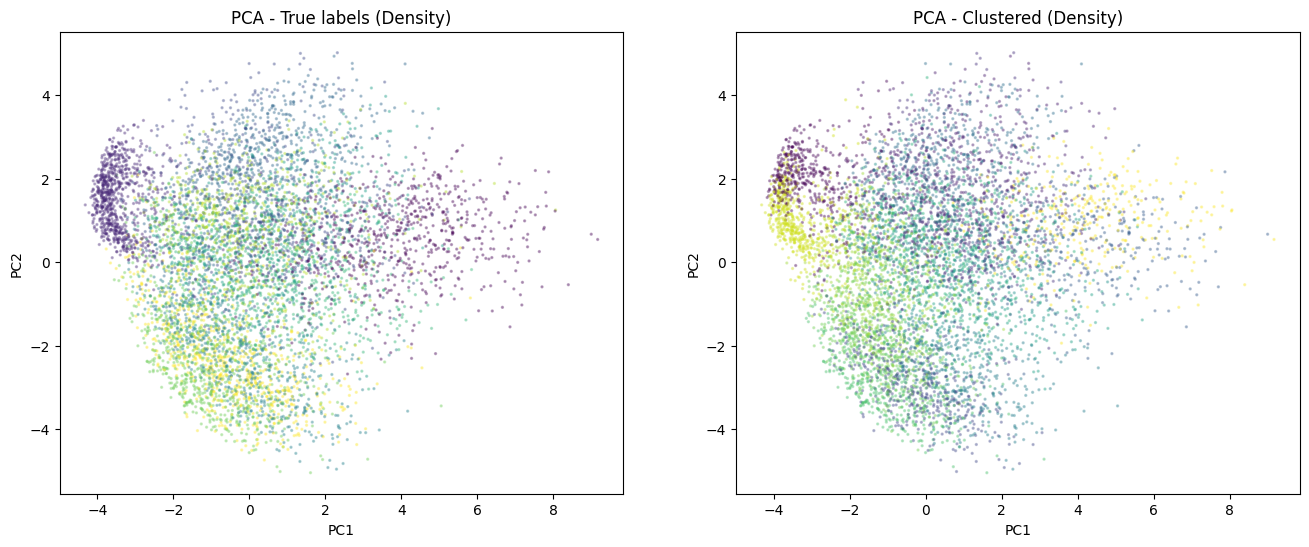

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=2, c=sample_y)
ax1.set_title('PCA - True labels (Density)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=2, c=labels)
ax2.set_title('PCA - Clustered (Density)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')



e. Describe the fit. Does this align with your expectation? (Note: The specific color used for the clusters and labels will not align, but do you see some of the same patterns emerge?)

The colors are very spread and mixed, which I didn't expect. Nevertheless, there seem to be clear clusters on the left side and the middle of the grid.




f. Display the cluster centroids as images in a grid using subplots. What digits do they most resemble?

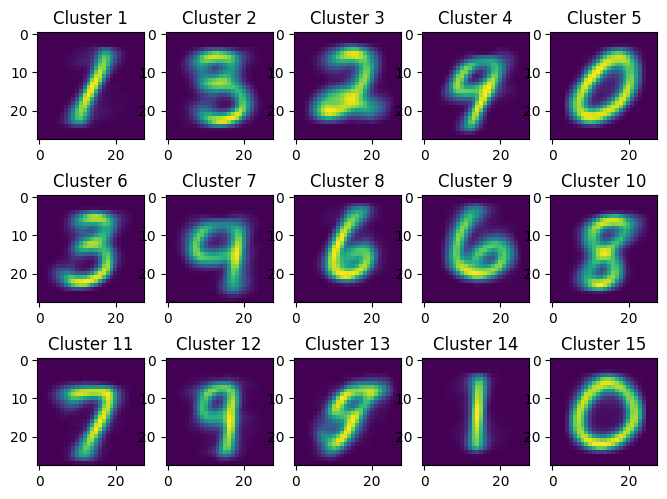

In [ ]:
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(3, 5, figsize=(8,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(kmeans.cluster_centers_[i].reshape(28,28))
    ax.set_title(f"Cluster {i+1}")

plt.show()


They resemble:
Centroid 1: 1. Centroid 2: 3. Centroid 3: 2. Centroid 4: 9. Centroid 5: 0.
Centroid 6: 3. Centroid 7: 9. Centroid 8: 6. Centroid 9: 6. Centroid 10: 8.
Centroid 11: 7. Centroid 12: 9. Centroid 13: 9. Centroid 14: 1. Centroid 15: 0.

### 3. Hierarchical Clustering
Here you will be performing hierarchical clustering on a smaller data subset.

Here you will be comparing linkage methods and metrics. Use the following linkage/metric combinations:

| Linkage Method | Metrics              |
|---------------|----------------------|
| Ward         | Euclidean            |
| Complete     | Euclidean, Cosine |

a. Get a subset of 10% of your original subset (you should have 700 points).

In [ ]:
sub_sample_X = sample_X.sample(frac=0.1, random_state=42)
sub_sample_y = sample_y.loc[sub_sample_X.index]

b. Fit hierarhiccal clustering with 10 clusters for each combination and store the silhouette scores.

In [ ]:
model1 = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward',
    metric='euclidean'
)

label1= model1.fit_predict(sub_sample_X)

model2= AgglomerativeClustering(
    n_clusters=10,
    linkage='complete',
    metric='cosine'
)
label2= model2.fit_predict(sub_sample_X)
score1=silhouette_score(sub_sample_X,label1,metric= "euclidean")
score2=silhouette_score(sub_sample_X,label2, metric = "cosine")

print(score1,score2)

0.04257497405017775 0.06280570930665275


c. According to the silhouette scores, which combination is best?

The complete linkage with cosine metrics is better, since with it each point is closer to its own cluster than to the next closest. We know since the score for this combination is 0.062806, which is bigger than 0.042575 from the other combination.

### 4. Visualizing Clustered Digits

a. Pick one of the cluster labels from your best models (k-means or HC). Select a random subset of 20 points belonging to that cluster.  

In [ ]:
indices = np.where(labels == 5)[0] #cluster 6, digit 3

sample_indices = np.random.choice(indices, 20, replace=False)

sample_points = sample_X.iloc[sample_indices].values

b. Using subplots (4 rows, 5 columns), plot the 20 digit images.  

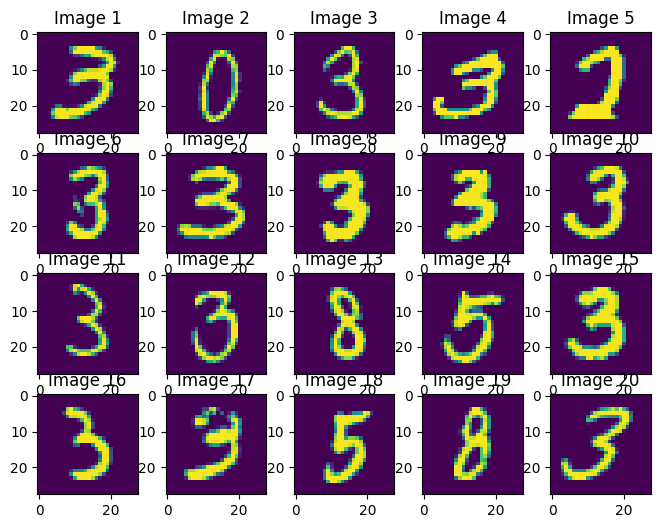

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(8,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_points[i].reshape(28,28))
    ax.set_title(f"Image {i+1}")

plt.show()

c. Comment on the clustered points (e.g., do they look similar?, are the representing the same digit?, etc.)

Most of them look like a 3, which correlates with the centroid. Nevertheless, some are 5,8 or a weird 2, which are more similar to 3 than any other number. The most different is a single 0.